$f(x, y) = 20 + x^2 - 10 \cos(2\pi x) + y^2 - 10 \cos(2\pi y)$

$f(\mathbf{x}) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10 \cos(2\pi x_i) \right]$

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [43]:
def rastrigin_func(x):
    d = x.shape[1] # dimension of the input 
    return 10 * d + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=1)

x = np.array([-2, 0.5, 3])
print(f"Func value in {x.reshape(1,3)} = {rastrigin_func(x.reshape(1,3))}")

x_2 = np.array([-2, 3])
print(f"Func value in {x_2.reshape(1,2)} = {rastrigin_func(x_2.reshape(1,2))}")

Func value in [[-2.   0.5  3. ]] = [33.25]
Func value in [[-2  3]] = [13.]


X shape: (100, 100)
X: [-5.12       -5.01656566 -4.91313131 -4.80969697 -4.70626263 -4.60282828
 -4.49939394 -4.3959596  -4.29252525 -4.18909091 -4.08565657 -3.98222222
 -3.87878788 -3.77535354 -3.67191919 -3.56848485 -3.46505051 -3.36161616
 -3.25818182 -3.15474747 -3.05131313 -2.94787879 -2.84444444 -2.7410101
 -2.63757576 -2.53414141 -2.43070707 -2.32727273 -2.22383838 -2.12040404
 -2.0169697  -1.91353535 -1.81010101 -1.70666667 -1.60323232 -1.49979798
 -1.39636364 -1.29292929 -1.18949495 -1.08606061 -0.98262626 -0.87919192
 -0.77575758 -0.67232323 -0.56888889 -0.46545455 -0.3620202  -0.25858586
 -0.15515152 -0.05171717  0.05171717  0.15515152  0.25858586  0.3620202
  0.46545455  0.56888889  0.67232323  0.77575758  0.87919192  0.98262626
  1.08606061  1.18949495  1.29292929  1.39636364  1.49979798  1.60323232
  1.70666667  1.81010101  1.91353535  2.0169697   2.12040404  2.22383838
  2.32727273  2.43070707  2.53414141  2.63757576  2.7410101   2.84444444
  2.94787879  3.05131313  3.15

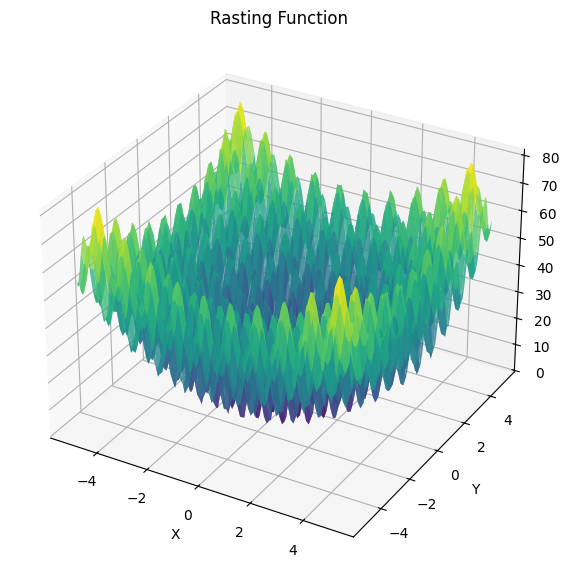

In [44]:
# Vizualiza the function
x = np.linspace(-5.12, 5.12, 100)
y = np.linspace(-5.12, 5.12, 100)

# Create grid of points
X, Y = np.meshgrid(x, y)
# Explore X Y
print(f"X shape: {X.shape}")
print(f"X: {X[1]}, Len: {len(X)}")
print(f"X ravel: {X.ravel()}")

points_matrix = np.vstack([X.ravel(), Y.ravel()]).T # makes sheet where 100*100 rows and two columns: x,y
Z = rastrigin_func(points_matrix).reshape(X.shape)

# Plot the surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_title('Rasting Function')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

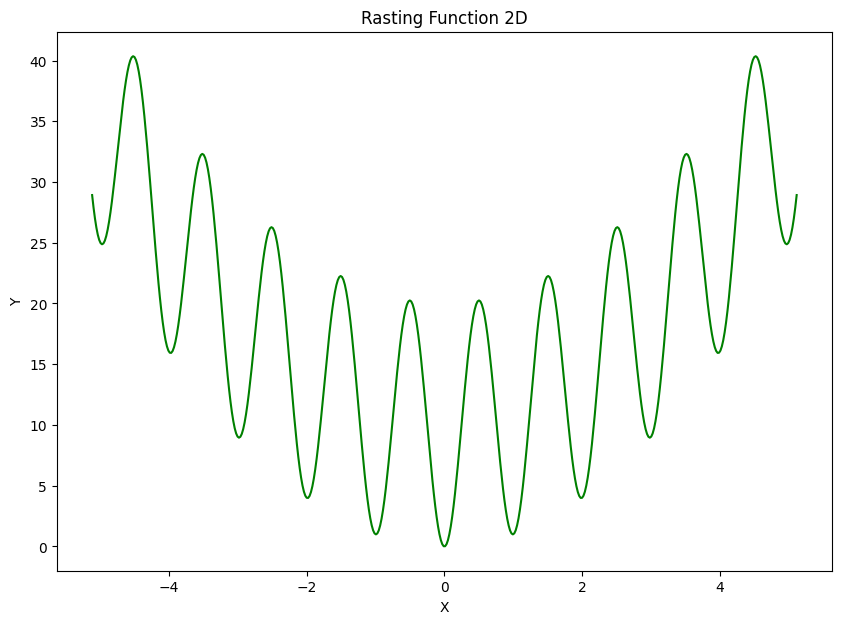

In [45]:
# Vizualiza the function
x_2d = np.linspace(-5.12, 5.12, 500)
Y_2d = rastrigin_func(x_2d.reshape(500,1))

# Plot the surface
plt.figure(figsize=(10, 7))
plt.plot(x_2d, Y_2d, color='green')
plt.title('Rasting Function 2D')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [46]:
# Generate initial population
def initial_pop(size, dim, bounce):
    pop = np.random.uniform(bounce[0], bounce[1], (size, dim))
    return pop 

# Test Call
test_pop = initial_pop(5, 2, [-5.12, 5.12])
print(f"Initial Population Shape: {test_pop.shape}")
print(f"Initial Population: {test_pop}")

Initial Population Shape: (5, 2)
Initial Population: [[-2.28580275  1.20569642]
 [ 4.06758191  2.32922361]
 [-2.26905927  2.17503704]
 [-3.99249241 -4.77532635]
 [ 0.75000077 -3.84721175]]


In [ ]:
def evaluate_fitness(population, dimension=2):
    return rastrigin_func(x=population)

# Test Call
print(evaluate_fitness(test_pop))

[26.161361   37.63332294 26.53625438 47.17026683 29.62826576]
